# Unit 3 code companion: Linear Regression

Fit a line, read the coefficient table, add and remove variables, and put a category in the model. Short cells, meant to be run one at a time.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

## Setup



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
cars.head()

,mpg,cylinder,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,American,chevrolet
1,15.0,8,350.0,165,3693,11.5,70,American,buick
2,18.0,8,318.0,150,3436,11.0,70,American,plymouth
3,16.0,8,304.0,150,3433,12.0,70,American,amc
4,17.0,8,302.0,140,3449,10.5,70,American,ford


## 1. Look at the data first



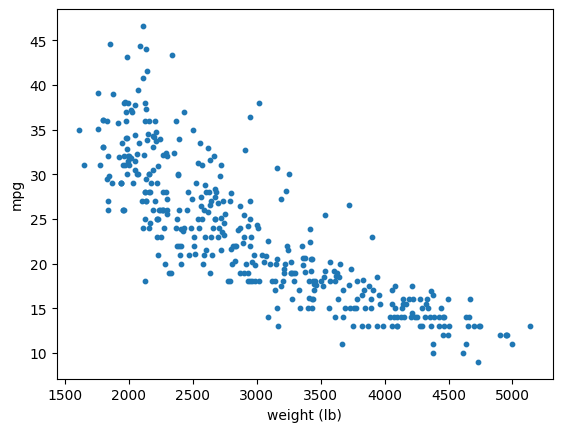

In [2]:
plt.scatter(cars.weight, cars.mpg, s=10)
plt.xlabel("weight (lb)"); plt.ylabel("mpg"); plt.show()

## 2. Fit the line



`"mpg ~ weight"` reads as *mpg explained by weight*. The outcome goes on the left.

In [3]:
fit = smf.ols("mpg ~ weight", data=cars).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          6.02e-102
Time:                        05:19:39   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.2165      0.799     57.867      0.0

## 3. The coefficient table is the part you read



In [4]:
print(fit.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.2165      0.799     57.867      0.000      44.646      47.787
weight        -0.0076      0.000    -29.645      0.000      -0.008      -0.007


`coef` is the slope, `std err` its standard error, `t` the slope divided by that standard error, `P>|t|` the p-value for a true slope of zero, and the last two columns the 95% interval. The p-value here is 0.000, so a slope this far from zero would be very surprising if weight had no relationship with mpg.

## 4. Pull out one number at a time



In [5]:
print("slope   :", fit.params["weight"])
print("SE      :", fit.bse["weight"])
print("t       :", fit.tvalues["weight"])
print("p-value :", fit.pvalues["weight"])
print("interval:", fit.conf_int().loc["weight"].tolist())

slope   : -0.0076473425357795775
SE      : 0.0002579632782734319
t       : -29.64508199370015
p-value : 6.015296051436753e-102
interval: [-0.00815451519394173, -0.007140169877617425]


The slope is $-0.0076$ mpg per pound, which is $-7.6$ mpg per 1,000 pounds. Always rescale to units someone can picture.

## 5. How well does it fit?



In [6]:
print("R-squared  :", fit.rsquared)
print("residual SD:", fit.resid.std())

R-squared  : 0.6926304331206254
residual SD: 4.3271679976951605


$R^2$ is the share of the variation in mpg the line accounts for. The residual SD says a typical car sits about that many mpg off the line.

## 6. Look at what the line missed



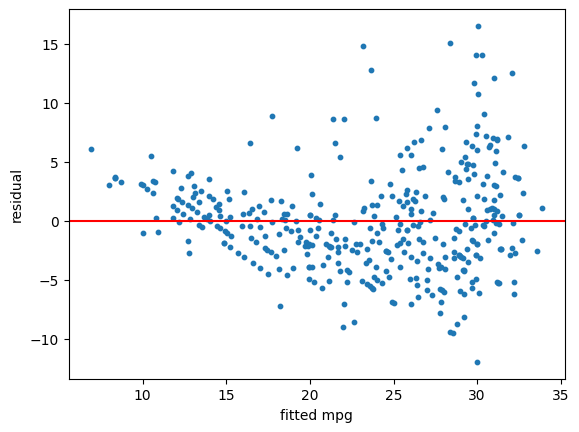

In [7]:
plt.scatter(fit.fittedvalues, fit.resid, s=10)
plt.axhline(0, color="red")
plt.xlabel("fitted mpg"); plt.ylabel("residual"); plt.show()

These residuals curve, which says a straight line is not quite the right shape here.

## 7. Add a variable



In [8]:
fit2 = smf.ols("mpg ~ weight + horsepower", data=cars).fit()
print(fit2.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     45.6402      0.793     57.540      0.000      44.081      47.200
weight        -0.0058      0.001    -11.535      0.000      -0.007      -0.005
horsepower    -0.0473      0.011     -4.267      0.000      -0.069      -0.026


In [9]:
print("weight alone      :", fit.params["weight"])
print("weight + horsepower:", fit2.params["weight"])

weight alone      : -0.0076473425357795775
weight + horsepower: -0.0057941573648029165


The weight coefficient changed when horsepower joined the model. Now it means *holding horsepower fixed*, which is a different question from the one the first model answered.

## 8. Remove a variable



In [10]:
fit3 = smf.ols("mpg ~ weight + horsepower + acceleration", data=cars).fit()
print(fit3.pvalues.round(4))

Intercept       0.0000
weight          0.0000
horsepower      0.0032
acceleration    0.9866
dtype: float64


Acceleration has a large p-value, so we cannot tell its coefficient from zero with the other two already in the model. Drop it and the model is `fit2` again.

## 9. A yes/no predictor



In [11]:
cars["is_american"] = (cars.origin == "American").astype(int)
smf.ols("mpg ~ weight + is_american", data=cars).fit().params

Intercept      45.567396
weight         -0.007085
is_american    -1.638301
dtype: float64

A 0/1 predictor shifts the line up or down. Its coefficient is the gap between American and other cars of the same weight.

## 10. A category with several levels



In [12]:
smf.ols("mpg ~ weight + C(origin)", data=cars).fit().params

Intercept                43.732236
C(origin)[T.European]     0.970906
C(origin)[T.Japanese]     2.327150
weight                   -0.007027
dtype: float64

`C(origin)` makes one level the baseline, here American, and each coefficient compares its level to that baseline.

## 11. Predict a new case



In [13]:
new = pd.DataFrame({"weight": [3000], "horsepower": [110]})
fit2.predict(new)

0    23.054424
dtype: float64

Weight runs from 1,613 to 5,140 pounds in this data, so 3,000 is a fair question. A 6,000-pound truck would not be.